<a href="https://colab.research.google.com/github/brainsocheul/VLM-study/blob/main/VLM_study_project_med.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#런타임 유형 변경해야!!

!pip install -q -U \
    transformers \
    accelerate \
    bitsandbytes \
    datasets \
    huggingface_hub \
    openai \
    pandas==2.2.3 \
    pillow==11.3.0 \
    tqdm \
    google-genai
#!pip install -q google-auth==2.49.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [ ]:
from google.colab import userdata
from google import genai

gemini_client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

GEMINI_EVALUATOR_MODEL = "gemini-3.5-flash-lite"

In [ ]:
#라이브러리 설치 확인 및 gpu 확인

import sys
import torch
import transformers
import accelerate
import bitsandbytes

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("bitsandbytes:", bitsandbytes.__version__)

print()

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU NOT AVAILABLE")

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA: 12.8
Transformers: 5.16.1
Accelerate: 1.14.0
bitsandbytes: 0.50.2

GPU: Tesla T4


In [ ]:
#google drive mount

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#output directory

import os

OUTPUT_DIR = "/content/drive/MyDrive/SGMRI_VQA_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/content/drive/MyDrive/SGMRI_VQA_results


In [ ]:
#dataset loading

from datasets import load_dataset

dataset = load_dataset(
    "BBexist/SGMRI-VQA-fixed",
    "image_qa",
    split="brain_val"
)

print(dataset)
print()
print(dataset.column_names)

README.md:   0%|          | 0.00/6.29k [00:00<?, ?B/s]

image_qa/brain_train.parquet: reconstructing file:   0%|          |  0.00B /  657MB            

image_qa/brain_train.parquet: downloading bytes:           |  0.00B            

image_qa/brain_val.parquet: reconstructing file:   0%|          |  0.00B /  194MB            

image_qa/brain_val.parquet: downloading bytes:           |  0.00B            

...

Generating brain_train split:   0%|          | 0/12193 [00:00<?, ? examples/s]

Generating brain_val split:   0%|          | 0/3704 [00:00<?, ? examples/s]

Generating knee_train split:   0%|          | 0/12495 [00:00<?, ? examples/s]

Generating knee_val split:   0%|          | 0/3750 [00:00<?, ? examples/s]

Dataset({
    features: ['volume_id', 'slice_num', 'modality', 'image_path', 'image', 'level', 'task', 'type', 'question', 'answer', 'reasoning', 'ground_truth_labels', 'ground_truth_diagnosis', 'ground_truth_bboxes', 'choices'],
    num_rows: 3704
})

['volume_id', 'slice_num', 'modality', 'image_path', 'image', 'level', 'task', 'type', 'question', 'answer', 'reasoning', 'ground_truth_labels', 'ground_truth_diagnosis', 'ground_truth_bboxes', 'choices']


In [ ]:
#test dataset sampling

N_IMAGES = 20


selected_indices = []


for n in range(N_IMAGES):

    q1_idx = 5 * n
    q2_idx = 5 * n + 1


    if q1_idx < len(dataset):

        selected_indices.append(
            q1_idx
        )


    if q2_idx < len(dataset):

        selected_indices.append(
            q2_idx
        )


test_dataset = dataset.select(
    selected_indices
)


# 원래 dataset index 보존
test_dataset = (
    test_dataset.add_column(

        "original_dataset_index",

        selected_indices

    )
)


print(
    "Number of images:",
    len(test_dataset) // 2
)

print(
    "Number of selected rows:",
    len(test_dataset)
)

print(
    "Original indices:",
    selected_indices
)

Flattening the indices:   0%|          | 0/40 [00:00<?, ? examples/s]

Number of images: 20
Number of selected rows: 40
Original indices: [0, 1, 5, 6, 10, 11, 15, 16, 20, 21, 25, 26, 30, 31, 35, 36, 40, 41, 45, 46, 50, 51, 55, 56, 60, 61, 65, 66, 70, 71, 75, 76, 80, 81, 85, 86, 90, 91, 95, 96]


Task: localization
Type: closed_ended
Question: Where is the posttreatment change located?
Answer: In the left hemisphere, <bbx>[175,192,21,34]</bbx>, <bbx>[188,179,21,30]</bbx>


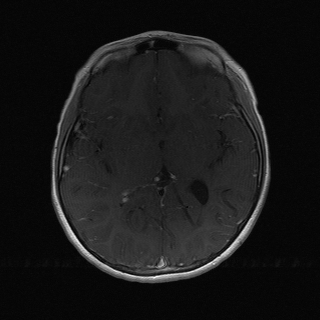

In [ ]:
#checking one sample

row = test_dataset[3]

print("Task:", row["task"])
print("Type:", row["type"])
print("Question:", row["question"])
print("Answer:", row["answer"])
display(row["image"])

In [ ]:
# Build questions for sequential VQA

def build_question(row):
    return row["question"]



# clean localizatoin answer

import re


def clean_ground_truth(answer):

    if answer is None:
        return None

    text = str(answer)

    # <bbx>...</bbx> 제거
    text = re.sub(
        r"<bbx>.*?</bbx>",
        "",
        text
    )

    # 남은 쉼표/공백 정리
    text = re.sub(
        r"\s*,\s*,*",
        ", ",
        text
    )

    text = text.strip(" ,")

    return text

In [ ]:
#quantization

import torch

from transformers import BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(

    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_compute_dtype=torch.float16,

    bnb_4bit_use_double_quant=True
)

In [ ]:
#loading LLaVA_med model


import torch

from transformers import (
    AutoProcessor,
    LlavaForConditionalGeneration
)


LLAVA_MED_MODEL = (
    "chaoyinshe/llava-med-v1.5-mistral-7b-hf"
)


print("Loading LLaVA-Med...")


processor_med = AutoProcessor.from_pretrained(
    LLAVA_MED_MODEL
)


model_med = (
    LlavaForConditionalGeneration
    .from_pretrained(

        LLAVA_MED_MODEL,

        quantization_config=quantization_config,

        device_map="auto",

        torch_dtype=torch.float16,

        low_cpu_mem_usage=True
    )
)


model_med.eval()


print("LLaVA-Med loaded.")

Loading LLaVA-Med...


processor_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

LLaVA-Med loaded.


In [ ]:
import time
from google.genai.errors import ClientError


def evaluate_with_gemini(
    client,
    evaluator_model,
    question,
    ground_truth,
    prediction,
    max_retries=5
):
    evaluator_input = f"""
Question: {question}

Ground truth: {ground_truth}

VLM answer: {prediction}

Based on the ground truth, can the VLM answer be accepted as correct?
""".strip()

    for attempt in range(max_retries):

        try:

            response = client.models.generate_content(
                model=evaluator_model,
                contents=evaluator_input,
                config={
                    "response_mime_type": "application/json",
                    "response_schema": EvaluationResult,
                }
            )

            result = EvaluationResult.model_validate_json(
                response.text
            )

            # 5 RPM 안전 간격
            time.sleep(13)

            return result.correct


        except ClientError as e:

            if e.code == 429:

                wait_time = 15 * (attempt + 1)

                print(
                    f"Gemini rate limit reached. "
                    f"Retrying after {wait_time}s..."
                )

                time.sleep(wait_time)

            else:
                raise


    raise RuntimeError(
        "Gemini evaluation failed after retries."
    )

In [ ]:
#defining function to ask llava-med questions

def ask_llava_med(
    model,
    processor,
    image,
    question,
    max_new_tokens=32
):
    image = image.convert("RGB")

    # LLaVA-style prompt 직접 구성
    prompt = f"""USER: <image>
{question}
ASSISTANT:"""

    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    )

    input_length = inputs["input_ids"].shape[1]

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    if "pixel_values" in inputs:
        inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True
        )

    generated_ids = output_ids[:, input_length:]

    answer = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return answer.strip()

In [ ]:
# ====================================
# Sequential VQA inference
# ====================================
import pandas as pd

def run_llava_med_on_dataset(
    model,
    processor,

    model_id,
    model_name,

    dataset,
    output_dir,

    gemini_client,
    evaluator_model,

    max_new_tokens=32,
    save_every=5
):

    # ====================================
    # Output path
    # ====================================

    output_path = os.path.join(
        output_dir,
        f"{model_name}_sequential_results.csv"
    )


    # ====================================
    # Dataset check
    # ====================================

    if len(dataset) % 2 != 0:

        print(
            "WARNING: dataset has an odd number of rows."
        )

        print(
            "The last unpaired row will be ignored."
        )


    # test_dataset에는
    # 이미지 하나당 Q1, Q2 두 row가 들어 있음
    n_images = len(dataset) // 2


    print(
        "Number of images:",
        n_images
    )


    # ====================================
    # Previous results
    # ====================================

    if os.path.exists(
        output_path
    ):

        previous_df = pd.read_csv(
            output_path
        )

        completed_indices = set()

        results = []


        for _, previous_row in previous_df.iterrows():

            # ====================================
            # Q1이 정상적으로 끝났는지
            # ====================================

            q1_complete = (

                pd.notna(
                    previous_row.get(
                        "q1_prediction"
                    )
                )

                and

                pd.notna(
                    previous_row.get(
                        "q1_correct"
                    )
                )

                and

                pd.isna(
                    previous_row.get(
                        "q1_inference_error"
                    )
                )

                and

                pd.isna(
                    previous_row.get(
                        "q1_evaluation_error"
                    )
                )

            )


            if not q1_complete:
                continue


            # ====================================
            # q2_asked 값 읽기
            # ====================================

            q2_asked = previous_row.get(
                "q2_asked"
            )


            # CSV를 다시 읽으면
            # "True" / "False" 문자열일 수도 있음
            if isinstance(
                q2_asked,
                str
            ):

                q2_asked = (
                    q2_asked
                    .strip()
                    .lower()
                    == "true"
                )


            # ====================================
            # Q2가 필요 없었던 경우
            #
            # 정상 이미지
            # 또는
            # 비정상이지만 Q1 오답
            #
            # → Q1만 성공했으면 완료
            # ====================================

            if not q2_asked:

                image_index = int(
                    previous_row[
                        "image_index"
                    ]
                )

                completed_indices.add(
                    image_index
                )

                results.append(
                    previous_row.to_dict()
                )

                continue


            # ====================================
            # Q2를 진행했던 경우
            # ====================================

            q2_complete = (

                pd.notna(
                    previous_row.get(
                        "q2_prediction"
                    )
                )

                and

                pd.notna(
                    previous_row.get(
                        "q2_correct"
                    )
                )

                and

                pd.isna(
                    previous_row.get(
                        "q2_inference_error"
                    )
                )

                and

                pd.isna(
                    previous_row.get(
                        "q2_evaluation_error"
                    )
                )

            )


            if q2_complete:

                image_index = int(
                    previous_row[
                        "image_index"
                    ]
                )

                completed_indices.add(
                    image_index
                )

                results.append(
                    previous_row.to_dict()
                )


        print(
            "Existing completed images:",
            len(completed_indices)
        )


    else:

        completed_indices = set()

        results = []


    # ====================================
    # 저장 주기용 counter
    # ====================================

    processed_since_save = 0


    # ====================================
    # Main inference loop
    # ====================================

    for image_idx in tqdm(
        range(n_images)
    ):

        # 이미 완료한 이미지는 skip
        if image_idx in completed_indices:
            continue


        # ====================================
        # Q1 / Q2 row 가져오기
        # ====================================

        q1_row_index = 2 * image_idx

        q2_row_index = (
            2 * image_idx + 1
        )


        q1_row = dataset[
            q1_row_index
        ]

        q2_row = dataset[
            q2_row_index
        ]


        # ====================================
        # 원래 dataset index
        # ====================================

        q1_original_index = q1_row.get(
            "original_dataset_index",
            q1_row_index
        )

        q2_original_index = q2_row.get(
            "original_dataset_index",
            q2_row_index
        )


        # ====================================
        # 같은 이미지인지 확인
        # ====================================

        if (
            q1_row["volume_id"]
            != q2_row["volume_id"]

            or

            q1_row["slice_num"]
            != q2_row["slice_num"]
        ):

            raise ValueError(

                f"Q1/Q2 image mismatch "
                f"at image_index={image_idx}"

            )


        # ====================================
        # Q1
        # ====================================

        # 데이터셋의 원래 질문 그대로 사용
        q1_question = (
            q1_row["question"]
        )

        q1_ground_truth = (
            q1_row["answer"]
        )


        q1_prediction = None

        q1_correct = None

        q1_inference_error = None

        q1_evaluation_error = None


        # ------------------------------------
        # Q1 LLaVA inference
        # ------------------------------------

        try:

            q1_prediction = (
                ask_llava_med(

                    model=model,

                    processor=processor,

                    image=
                        q1_row["image"],

                    question=
                        q1_question,

                    max_new_tokens=
                        max_new_tokens

                )
            )


        except Exception as e:

            q1_inference_error = repr(
                e
            )

            print(
                f"\nQ1 inference ERROR "
                f"at image {image_idx}:",
                q1_inference_error
            )


        # ------------------------------------
        # Q1 GPT evaluation
        # ------------------------------------

        if q1_prediction is not None:

            try:

                q1_correct = (
                    evaluate_with_gemini(

                        client=
                            gemini_client,

                        evaluator_model=
                            evaluator_model,

                        question=
                            q1_question,

                        ground_truth=
                            q1_ground_truth,

                        prediction=
                            q1_prediction
                    )
                )


            except Exception as e:

                q1_evaluation_error = repr(
                    e
                )

                print(
                    f"\nQ1 GPT ERROR "
                    f"at image {image_idx}:",
                    q1_evaluation_error
                )


        # ====================================
        # 이미지가 실제 abnormal인지 확인
        # ====================================

        is_abnormal = (

            str(
                q1_ground_truth
            )
            .strip()
            .lower()
            .rstrip(".")

            == "yes"

        )


        # ====================================
        # Q2 기본값
        # ====================================

        q2_asked = False

        q2_question = None

        q2_ground_truth = None

        q2_prediction = None

        q2_correct = None

        q2_inference_error = None

        q2_evaluation_error = None


        # ====================================
        # Q2 진행
        #
        # 1. 실제 abnormal image
        # 2. GPT가 Q1을 correct라고 판정
        #
        # 둘 다 만족할 때만 실행
        # ====================================

        if (
            is_abnormal
            and q1_correct is True
        ):

            q2_asked = True


            # 데이터셋의 원래 localization 질문
            q2_question = (
                q2_row["question"]
            )


            q2_ground_truth = (
                clean_ground_truth(q2_row["answer"])
            )


            # --------------------------------
            # Q2 LLaVA inference
            # --------------------------------

            try:

                q2_prediction = (
                    ask_llava_med(

                        model=model,

                        processor=
                            processor,

                        image=
                            q2_row["image"],

                        question=
                            q2_question,

                        max_new_tokens=
                            max_new_tokens

                    )
                )


            except Exception as e:

                q2_inference_error = repr(
                    e
                )

                print(
                    f"\nQ2 inference ERROR "
                    f"at image {image_idx}:",
                    q2_inference_error
                )


            # --------------------------------
            # Q2 GPT evaluation
            # --------------------------------

            if q2_prediction is not None:

                try:

                    q2_correct = (
                        evaluate_with_gemini(

                            client=
                                gemini_client,

                            evaluator_model=
                                evaluator_model,

                            question=
                                q2_question,

                            ground_truth=
                                q2_ground_truth,

                            prediction=
                                q2_prediction
                        )
                    )


                except Exception as e:

                    q2_evaluation_error = (
                        repr(e)
                    )

                    print(
                        f"\nQ2 GPT ERROR "
                        f"at image {image_idx}:",
                        q2_evaluation_error
                    )


        # ====================================
        # 결과 저장
        # 이미지 하나당 CSV 한 줄
        # ====================================

        result = {

            # --------------------------------
            # Image information
            # --------------------------------

            "image_index":
                image_idx,

            "q1_dataset_index":
                q1_original_index,

            "q2_dataset_index":
                q2_original_index,

            "model":
                model_name,

            "model_id":
                model_id,

            "evaluator_model":
                evaluator_model,

            "volume_id":
                q1_row["volume_id"],

            "slice_num":
                q1_row["slice_num"],

            "modality":
                q1_row["modality"],

            "level":
                q1_row["level"],


            # =================================
            # Q1
            # =================================

            "q1_question":
                q1_question,

            "q1_ground_truth":
                q1_ground_truth,

            "q1_prediction":
                q1_prediction,

            "q1_correct":
                q1_correct,

            "q1_inference_error":
                q1_inference_error,

            "q1_evaluation_error":
                q1_evaluation_error,


            # 이미지 자체가 abnormal인지
            "is_abnormal":
                is_abnormal,


            # =================================
            # Q2
            # =================================

            "q2_asked":
                q2_asked,

            "q2_question":
                q2_question,

            "q2_ground_truth":
                q2_ground_truth,

            "q2_prediction":
                q2_prediction,

            "q2_correct":
                q2_correct,

            "q2_inference_error":
                q2_inference_error,

            "q2_evaluation_error":
                q2_evaluation_error,


            # =================================
            # Additional ground truth
            # =================================

            "ground_truth_labels":
                str(
                    q1_row.get(
                        "ground_truth_labels"
                    )
                ),

            "ground_truth_diagnosis":
                str(
                    q1_row.get(
                        "ground_truth_diagnosis"
                    )
                ),

            "ground_truth_bboxes":
                str(
                    q1_row.get(
                        "ground_truth_bboxes"
                    )
                )

        }


        results.append(
            result
        )


        processed_since_save += 1


        # ====================================
        # Intermediate save
        # ====================================

        if (
            processed_since_save
            >= save_every
        ):

            pd.DataFrame(
                results
            ).to_csv(
                output_path,
                index=False
            )

            processed_since_save = 0


    # ====================================
    # Final dataframe
    # ====================================

    result_df = pd.DataFrame(
        results
    )


    if len(result_df) > 0:

        result_df = (

            result_df
            .sort_values(
                "image_index"
            )
            .reset_index(
                drop=True
            )

        )


    # ====================================
    # Final save
    # ====================================

    result_df.to_csv(
        output_path,
        index=False
    )


    print()

    print(
        "Saved to:",
        output_path
    )


    # ====================================
    # Metrics
    # ====================================

    print()
    print("=" * 60)
    print("RESULTS")
    print("=" * 60)


    # ====================================
    # Q1 accuracy
    #
    # 정상 + 비정상 이미지 모두 포함
    # ====================================

    q1_valid = result_df[

        result_df[
            "q1_correct"
        ].notna()

    ]


    if len(q1_valid) > 0:

        q1_correct_count = (

            q1_valid[
                "q1_correct"
            ]
            .astype(bool)
            .sum()

        )

        q1_accuracy = (

            q1_correct_count
            / len(q1_valid)

        )


        print(
            "Q1 accuracy:",
            f"{q1_accuracy:.4f}",
            f"({q1_correct_count}/{len(q1_valid)})"
        )


    # ====================================
    # Q1 abnormal accuracy
    #
    # 실제 abnormal image만 따로
    # ====================================

    abnormal_q1 = result_df[

        (
            result_df[
                "is_abnormal"
            ] == True
        )

        &

        (
            result_df[
                "q1_correct"
            ].notna()
        )

    ]


    if len(abnormal_q1) > 0:

        abnormal_q1_correct = (

            abnormal_q1[
                "q1_correct"
            ]
            .astype(bool)
            .sum()

        )

        abnormal_q1_accuracy = (

            abnormal_q1_correct
            / len(abnormal_q1)

        )


        print(
            "Q1 abnormal accuracy:",
            f"{abnormal_q1_accuracy:.4f}",
            f"({abnormal_q1_correct}/{len(abnormal_q1)})"
        )


    # ====================================
    # Q2 conditional accuracy
    #
    # Q2까지 실제로 진행한 경우만
    # ====================================

    q2_valid = result_df[

        (
            result_df[
                "q2_asked"
            ] == True
        )

        &

        (
            result_df[
                "q2_correct"
            ].notna()
        )

    ]


    if len(q2_valid) > 0:

        q2_correct_count = (

            q2_valid[
                "q2_correct"
            ]
            .astype(bool)
            .sum()

        )

        q2_accuracy = (

            q2_correct_count
            / len(q2_valid)

        )


        print(
            "Q2 conditional accuracy:",
            f"{q2_accuracy:.4f}",
            f"({q2_correct_count}/{len(q2_valid)})"
        )


    # ====================================
    # End-to-end localization accuracy
    #
    # 전체 abnormal 이미지 기준
    #
    # Q1 실패 → localization 실패
    # Q2 실패 → localization 실패
    # ====================================

    abnormal_cases = result_df[

        result_df[
            "is_abnormal"
        ] == True

    ]


    if len(abnormal_cases) > 0:

        end_to_end_correct = (

            (
                abnormal_cases[
                    "q1_correct"
                ] == True
            )

            &

            (
                abnormal_cases[
                    "q2_correct"
                ] == True
            )

        )


        end_to_end_correct_count = (
            end_to_end_correct.sum()
        )

        end_to_end_accuracy = (

            end_to_end_correct_count
            / len(abnormal_cases)

        )


        print(
            "End-to-end localization accuracy:",
            f"{end_to_end_accuracy:.4f}",
            f"({end_to_end_correct_count}/{len(abnormal_cases)})"
        )


    print("=" * 60)


    return result_df

In [ ]:
# ====================================
# Run experiment
# ====================================

from tqdm.auto import tqdm

result_df = (
    run_llava_med_on_dataset(

        model=
            model_med,

        processor=
            processor_med,

        model_id=
            LLAVA_MED_MODEL,

        model_name=
            "llava_med",

        dataset=
            test_dataset,

        output_dir=
            OUTPUT_DIR,

        gemini_client=
            gemini_client,

        evaluator_model=
            GEMINI_EVALUATOR_MODEL,

        max_new_tokens=32,

        save_every=5

    )
)

Number of images: 20


  0%|          | 0/20 [00:00<?, ?it/s]


Saved to: /content/drive/MyDrive/SGMRI_VQA_results/llava_med_sequential_results.csv

RESULTS
Q1 accuracy: 0.3000 (6/20)
Q1 abnormal accuracy: 0.2222 (4/18)
Q2 conditional accuracy: 0.2500 (1/4)
End-to-end localization accuracy: 0.0556 (1/18)


In [ ]:
#print results

print(result_df.columns)

Index(['image_index', 'q1_dataset_index', 'q2_dataset_index', 'model',
       'model_id', 'evaluator_model', 'volume_id', 'slice_num', 'modality',
       'level', 'q1_question', 'q1_ground_truth', 'q1_prediction',
       'q1_correct', 'q1_inference_error', 'q1_evaluation_error',
       'is_abnormal', 'q2_asked', 'q2_question', 'q2_ground_truth',
       'q2_prediction', 'q2_correct', 'q2_inference_error',
       'q2_evaluation_error', 'ground_truth_labels', 'ground_truth_diagnosis',
       'ground_truth_bboxes'],
      dtype='object')

In [ ]:
print(result_df[["image_index", "q1_question", "q1_ground_truth", "q1_prediction", "q1_inference_error", "q1_evaluation_error", "is_abnormal"]])

    image_index                                 q1_question q1_ground_truth  \
0             0  Is there an abnormality in this MRI image?            Yes.   
1             1  Is there an abnormality in this MRI image?            Yes.   
2             2  Is there an abnormality in this MRI image?            Yes.   
3             3  Is there an abnormality in this MRI image?             No.   
4             4  Is there an abnormality in this MRI image?            Yes.   
5             5  Is there an abnormality in this MRI image?            Yes.   
6             6  Is there an abnormality in this MRI image?            Yes.   
7             7  Is there an abnormality in this MRI image?            Yes.   
8             8  Is there an abnormality in this MRI image?            Yes.   
9             9  Is there an abnormality in this MRI image?            Yes.   
10           10  Is there an abnormality in this MRI image?            Yes.   
11           11  Is there an abnormality in this MRI

In [ ]:
print(result_df[["image_index", "q2_asked", "q2_question", "q2_ground_truth", "q2_prediction", "q2_correct", "q2_inference_error", "q2_evaluation_error"]])

    image_index  q2_asked                               q2_question  \
0             0     False                                      None   
1             1     False                                      None   
2             2     False                                      None   
3             3     False                                      None   
4             4      True                Where is the mass located?   
5             5     False                                      None   
6             6      True  Where is the nonspecific lesion located?   
7             7      True          Where is the craniotomy located?   
8             8     False                                      None   
9             9      True               Where is the edema located?   
10           10     False                                      None   
11           11     False                                      None   
12           12     False                                      None   
13    

In [ ]:
# import os

# output_path = os.path.join(
#     OUTPUT_DIR,
#     "llava_med_sequential_results.csv"
# )

# if os.path.exists(output_path):
#     os.remove(output_path)
#     print("기존 결과 삭제 완료")
# else:
#     print("기존 결과 파일 없음")

기존 결과 삭제 완료


In [ ]:
result_df['q1_prediction']

,q1_prediction
0,"The mri image appears to be normal, with no si..."
1,"The mri image appears to be normal, with no si..."
2,"The mri image appears to be normal, with no si..."
3,"The MRI image appears to be normal, as there a..."
4,"Yes, there appears to be an abnormality in the..."
5,"The mri image appears to be normal, with no si..."
6,"Yes, there appears to be an abnormality in the..."
7,"Yes, there appears to be an abnormality in the..."
8,"The mri image appears to be normal, with no si..."
9,"Yes, there appears to be an abnormality in the..."
